# **ANNML MSE-2**
# **Daily Temperature - Linear Regression**

---

 
**Name:** Khushi Tomar  
**University Roll No.:** 202401100500086
**CSIT - B**

In [1]:
csv_path=r"C:\Projects\Project\ANN-ML-MSE2\09_daily_temperature.csv"
print(csv_path)

C:\Projects\Project\ANN-ML-MSE2\09_daily_temperature.csv


In [2]:
import pandas as pd
df=pd.read_csv(csv_path)
print(df.columns)
print(df.isnull)

Index(['day', 'temp_c', 'humidity_pct', 'wind_kmh', 'next_day_temp'], dtype='object')
<bound method DataFrame.isnull of      day  temp_c  humidity_pct  wind_kmh  next_day_temp
0      1   19.10          72.5      19.6          18.68
1      2   17.36          76.4      12.3          17.18
2      3   18.21          72.8      23.6          17.22
3      4   21.06          88.3       9.9          17.90
4      5   21.31          93.7      17.5          20.08
..   ...     ...           ...       ...            ...
725  726   16.14          84.8      24.2          17.10
726  727   16.90          67.3      16.6          19.36
727  728   16.31          85.3      14.8          14.76
728  729   22.51          75.3      21.0          21.88
729  730   21.63          85.2       0.9          21.48

[730 rows x 5 columns]>


In [3]:
df.drop("day",axis=1,inplace=True);

In [4]:
original_shape = df.shape
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outlier_mask=((df<(Q1-1.5*IQR))|(df>(Q3+1.5*IQR))).any(axis=1)
outliers=df[outlier_mask]

df=df[~outlier_mask]

print(f"Original shape:{original_shape}")
print(f"Shape after removing outliers:{df.shape}")
print(f"\nNumber of outliers removed:{len(outliers)}")
print(f"\nOutliers removed:")
print(outliers)

Original shape:(730, 4)
Shape after removing outliers:(729, 4)

Number of outliers removed:1

Outliers removed:
     temp_c  humidity_pct  wind_kmh  next_day_temp
426   26.88          61.3      39.6          27.25


In [5]:
y=df["next_day_temp"]
x=df.drop("next_day_temp",axis=1);

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [7]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [8]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred=model.predict(x_test)

In [10]:
from sklearn.metrics import mean_squared_error,r2_score
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

2.9796160994696095
0.9446128833828289


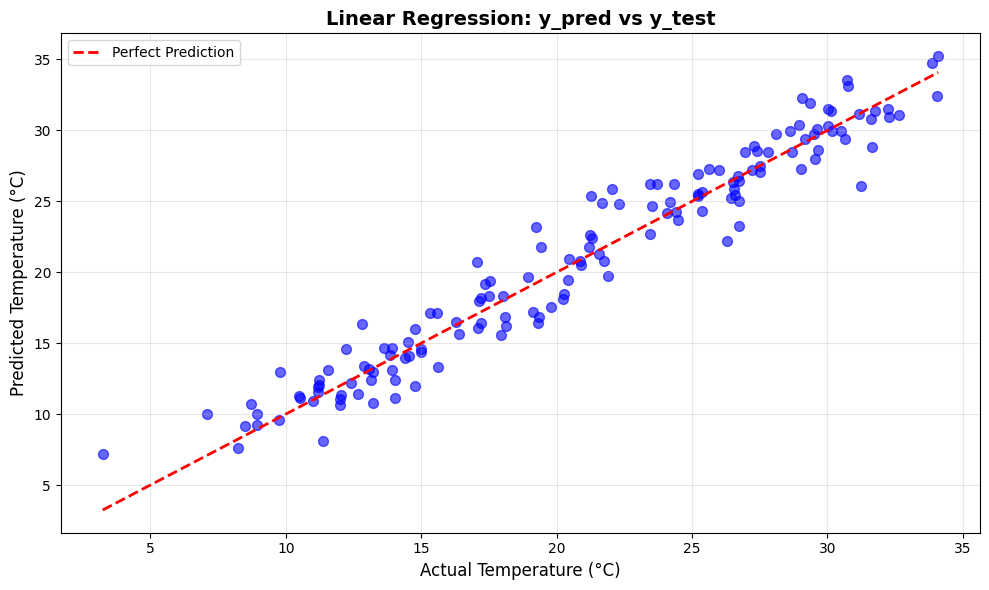

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('Linear Regression: y_pred vs y_test', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Read [](file:///c%3A/Projects/Project/ANN-ML-MSE2)

Read [](file:///c%3A/Projects/Project/ANN-ML-MSE2/09_daily_temperature.csv#1-1), lines 1 to 50

The CSV file contains weather data (temperature, humidity, wind, and next-day temperature), but it doesn't specify which model is used. Based on your folder name "ANN-ML-MSE2", it suggests an **Artificial Neural Network (ANN)** model optimized for Mean Squared Error (MSE).

However, I only see this CSV file in your workspace. Do you have Python code, a Jupyter notebook, or other files that use this dataset? I'd need to see the actual model code to tell you the specific architecture and configuration being used.